# Linear & Polynomial Regression: Engineering Intuition

## 1. The Core Equation (The Hypothesis)
At its core, linear regression is just finding the perfect mathematical weights to multiply your inputs by so you can predict an output. 

* **The Equation:** $$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_n x_n$$
* **Semantic Meaning:** * $x_1, x_2$ are your **features** (e.g., CPU Usage, Memory).
  * $\theta_1, \theta_2$ are the **weights** (or coefficients). Think of these as volume dials. The model learns which features are important and turns their "dial" up, while turning useless features down to zero.
  * $\theta_0$ is the **bias** (or y-intercept). It is the baseline assumption. If all your inputs are 0, what is the default output?

---

## 2. The Cost Function (Measuring "Wrongness")
Before a model can improve, it needs a metric to know exactly how badly it is currently failing. 

* **Mean Squared Error (MSE) Cost Function ($J(\theta)$):**
  $$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$
* **Semantic Meaning:** We take our model's prediction ($h_\theta(x)$), subtract the actual true value ($y$), and square the result. We square it for two reasons:
  1. It turns negative errors into positive numbers (so predicting 5 too high or 5 too low is treated equally).
  2. It massively penalizes extreme outliers. Being off by 10 costs you 100 penalty points. Being off by 1 costs you 1.

---

## 3. Convergence Algorithms (Finding the Best Line)
How does the computer actually adjust the $\theta$ weights to minimize that Cost Function? There are two main ways:

### A. The Normal Equation (The "Direct Math" Approach)
* **Equation:** $$\theta = (X^T X)^{-1} X^T y$$
* **Intuition:** This is a one-shot linear algebra calculation. It solves for the perfect weights instantly without needing any loops.
* **The Catch:** Calculating the inverse of a matrix ($(X^T X)^{-1}$) is computationally brutal. The time complexity is $O(n^3)$. When deploying models to production environments, especially on standard CPU-based instances without dedicated accelerators, running this on a dataset with millions of rows and thousands of features will instantly bottleneck your compute and crash the process.

### B. Gradient Descent (The "Iterative" Approach)
* **Equation:** $$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$
* **Intuition:** This acts like a `while` loop. The model takes a random guess, calculates the slope of the error, and takes a "step" downhill. $\alpha$ (the learning rate) is the step size. It repeats this loop until the error hits rock bottom (convergence). Because it steps through the data sequentially rather than loading a massive matrix into memory all at once, this is the industry standard for scaling machine learning models on standard server hardware.

---

## 4. Performance Metrics (Evaluating the Model)
Once the line is drawn, how do we grade its performance? 

* **MAE (Mean Absolute Error):**
  * *Formula:* $$\frac{1}{n} \sum |y - \hat{y}|$$
  * *Intuition:* The pure average of your errors. If your MAE is 5, it means "On average, my model's prediction is off by exactly 5 units." It is the easiest metric to explain to non-technical stakeholders.
* **MSE (Mean Squared Error):**
  * *Intuition:* (Discussed in Cost Function). Because it squares the errors, the final number is heavily inflated and in the "wrong" units (e.g., squared milliseconds). Hard to interpret, but great for forcing the model to care about outliers.
* **RMSE (Root Mean Squared Error):**
  * *Formula:* $$\sqrt{MSE}$$
  * *Intuition:* Takes the square root of the MSE to bring the metric back to the original units (e.g., milliseconds). It is highly popular because it gives you a readable number, but still mathematically punishes the model if it has a few massive, catastrophic errors.
* **$R^2$ (R-Squared / Coefficient of Determination):**
  * *Intuition:* "How much better is our model than just blindly guessing the average every single time?" An $R^2$ of `0.85` means your inputs successfully explain 85% of the variance in the data. `1.0` is perfect; `0.0` means your model is absolutely useless.
* **Adjusted $R^2$:**
  * *Intuition:* Standard $R^2$ artificially inflates if you just keep throwing random, useless features at the model. Adjusted $R^2$ acts as a penalty system: it strictly decreases your score if you add a feature that doesn't actually improve the predictions.

---

## 5. Polynomial Regression (The Curved Line)
Sometimes, data doesn't move in a straight line. If you track server response time as traffic scales, it might start flat and then curve upwards exponentially.

* **Equation:** $$h_\theta(x) = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3$$
* **Intuition:** Mathematically, the algorithm is still doing standard Multiple Linear Regression. We just engineer the features by feeding the algorithm $x^2$ and $x^3$ as if they were brand-new inputs. This allows the model to map out a flexible, curved line that follows the natural bend of the data.

---

## 6. Overfitting vs. Underfitting (The Balancing Act)
When you use Polynomial Regression, you control the "degree" of the curve (e.g., $x^2$ is a simple curve, $x^{15}$ is a highly complex, squiggly line).

* **Underfitting (High Bias):** Your model is too simple. You tried to draw a perfectly straight, rigid line through data that naturally curves. It performs terribly on training data and terrible in production.
* **Overfitting (High Variance):** Your model is too complex. You gave it too many polynomial degrees ($x^{15}$), so the line bends and snaps to connect *every single dot* perfectly. It essentially memorized the training data's noise. It gets a 100% score in testing, but completely fails when it sees brand-new production data.
* **The Goal:** A smooth curve that captures the general underlying trend without chasing every random anomaly.


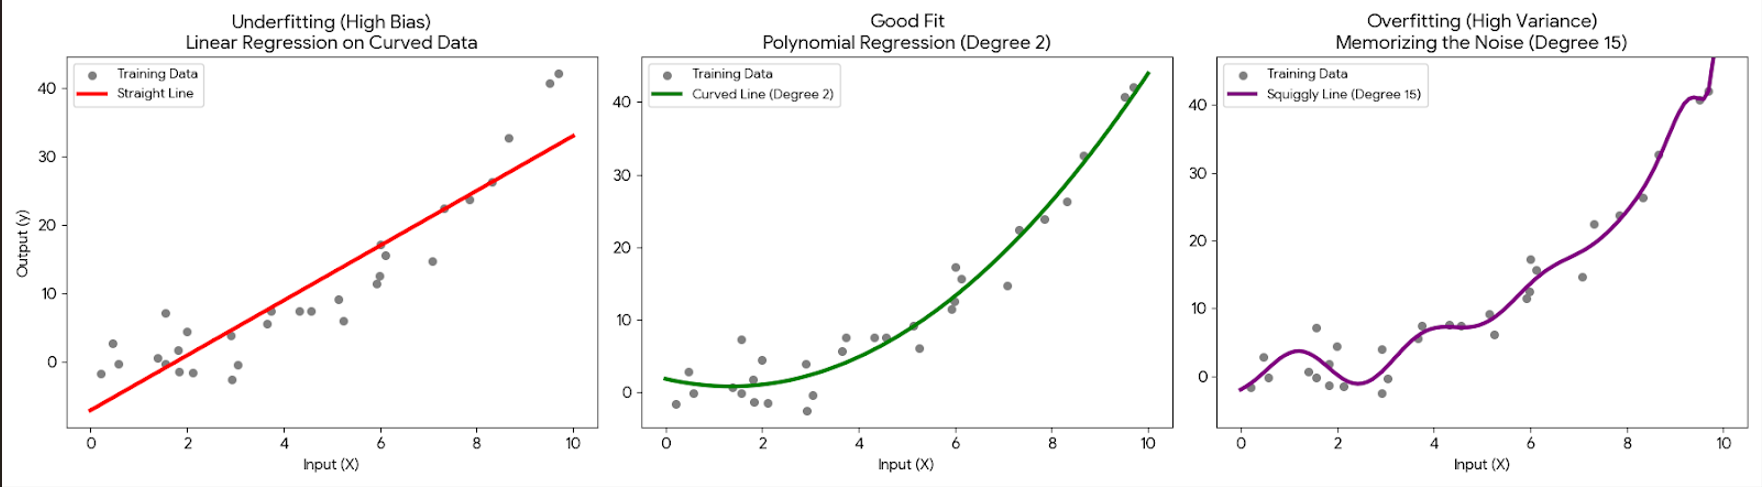